In [1]:
import seaborn as sns
print("All OK")

All OK


In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/GlobalLandTemperaturesByCountry.csv")

df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [6]:
df.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
Country                          0
dtype: int64

In [9]:
df['dt'] = pd.to_datetime(df['dt'])

In [10]:
df['year'] = df['dt'].dt.year

In [11]:
df = df.rename(columns={
    'AverageTemperature': 'temperature'
})

In [12]:
df.head()

,dt,temperature,AverageTemperatureUncertainty,Country,year
0,1743-11-01,4.384,2.294,Åland,1743
5,1744-04-01,1.530,4.680,Åland,1744
6,1744-05-01,6.702,1.789,Åland,1744
7,1744-06-01,11.609,1.577,Åland,1744
8,1744-07-01,15.342,1.410,Åland,1744


In [13]:
yearly_temp = df.groupby('year')['temperature'].mean()
yearly_temp.head()

year
1743    5.184140
1744    9.837898
1745    1.387125
1750    9.129353
1751    9.167388
Name: temperature, dtype: float64

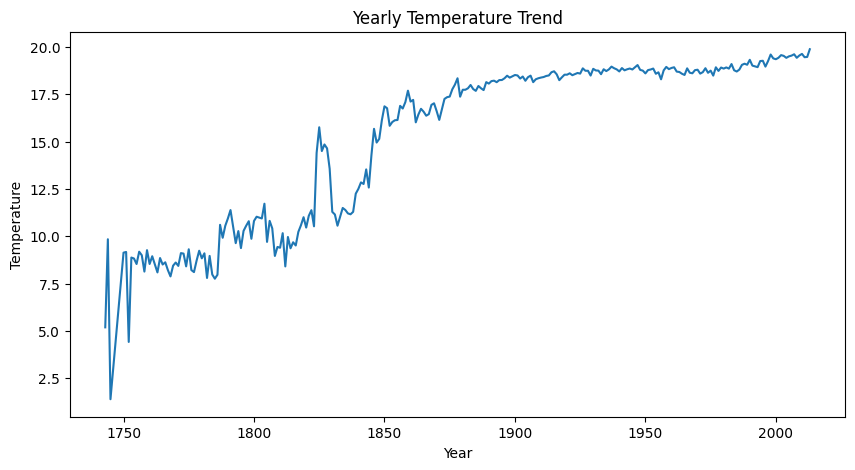

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(yearly_temp.index, yearly_temp.values)
plt.title("Yearly Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

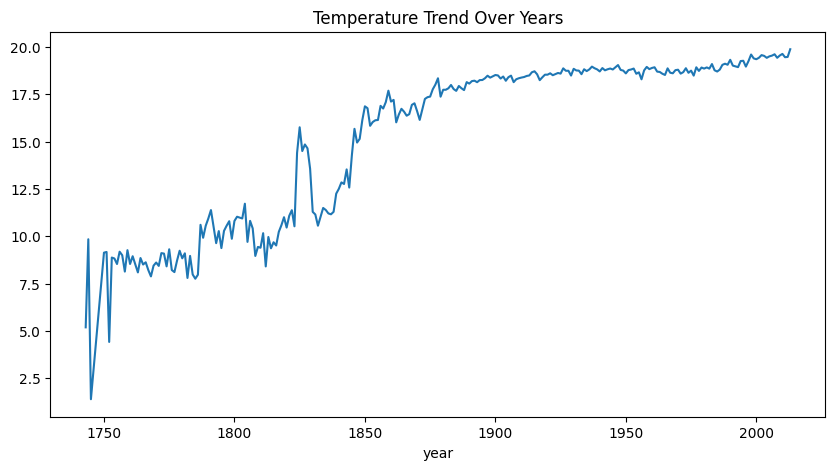

In [15]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_temp.index, y=yearly_temp.values)
plt.title("Temperature Trend Over Years")
plt.show()

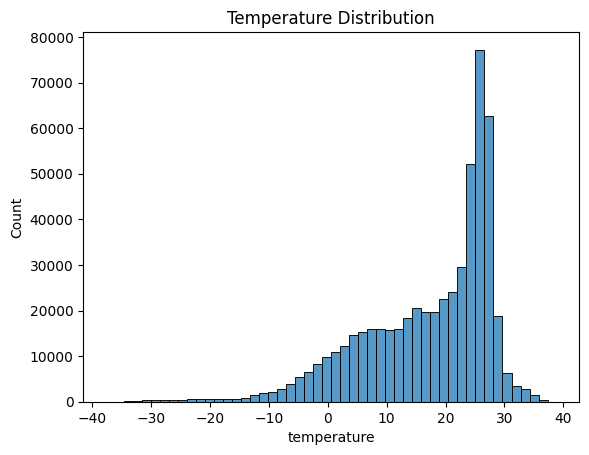

In [16]:
sns.histplot(df['temperature'], bins=50)
plt.title("Temperature Distribution")
plt.show()

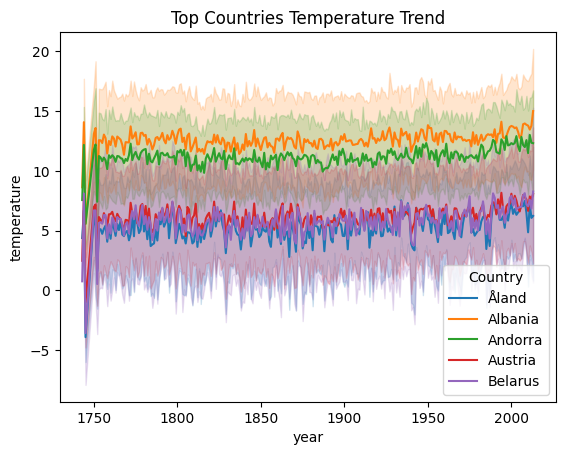

In [17]:
top_countries = df['Country'].value_counts().head(5).index

filtered = df[df['Country'].isin(top_countries)]

sns.lineplot(data=filtered, x='year', y='temperature', hue='Country')
plt.title("Top Countries Temperature Trend")
plt.show()

In [18]:
df['month'] = df['dt'].dt.month

In [19]:
df['rolling_temp'] = df['temperature'].rolling(window=12).mean()

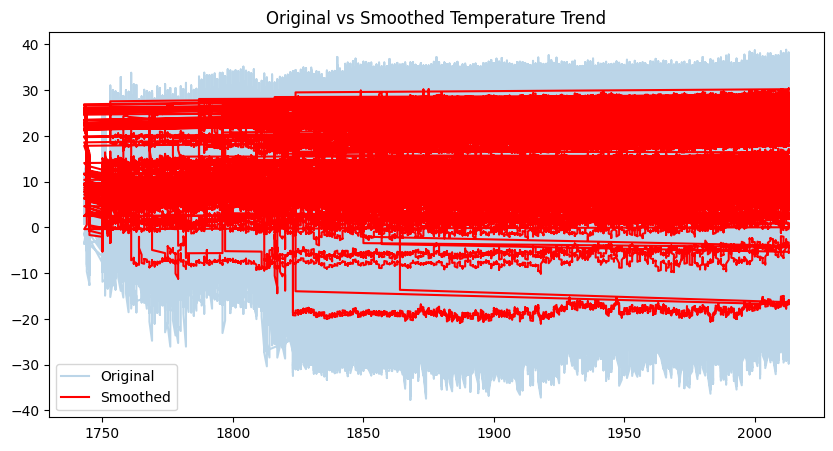

In [20]:
plt.figure(figsize=(10,5))
plt.plot(df['year'], df['temperature'], label='Original', alpha=0.3)
plt.plot(df['year'], df['rolling_temp'], label='Smoothed', color='red')
plt.legend()
plt.title("Original vs Smoothed Temperature Trend")
plt.show()

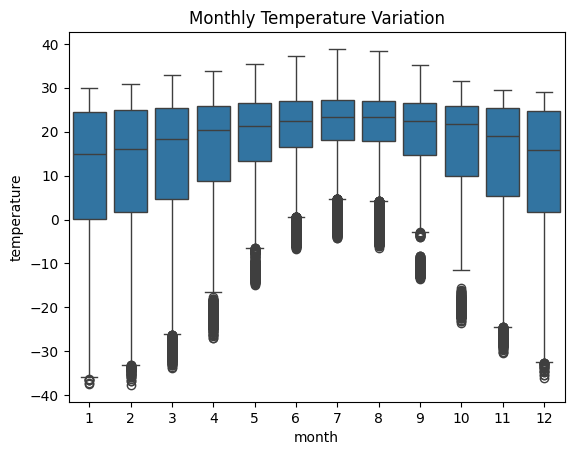

In [21]:
sns.boxplot(x='month', y='temperature', data=df)
plt.title("Monthly Temperature Variation")
plt.show()

In [22]:
yearly_summary = df.groupby('year')['temperature'].agg(['mean', 'min', 'max'])
yearly_summary.head()

,mean,min,max
year,,,
1743,5.184140,-3.571,11.809
1744,9.837898,-9.629,23.939
1745,1.387125,-12.564,12.707
1750,9.129353,-11.859,26.096
1751,9.167388,-14.845,25.283


In [23]:
yearly_temp = df.groupby('year')['temperature'].mean()

In [24]:
mean_temp = yearly_temp.mean()
std_temp = yearly_temp.std()

print(mean_temp, std_temp)

15.232008896934516 4.282833032210121


In [25]:
anomalies = yearly_temp[abs(yearly_temp - mean_temp) > 2 * std_temp]

anomalies

year
1743    5.184140
1745    1.387125
1752    4.413387
Name: temperature, dtype: float64

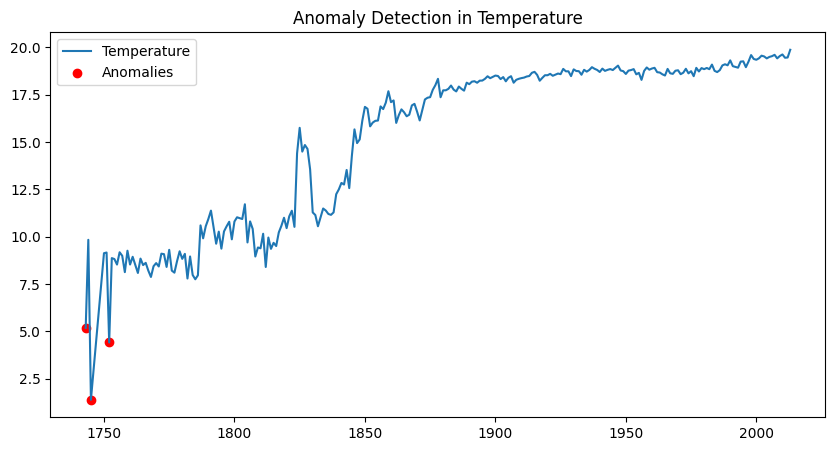

In [26]:
plt.figure(figsize=(10,5))

# Normal data
plt.plot(yearly_temp.index, yearly_temp.values, label='Temperature')

# Anomalies highlight
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomalies')

plt.legend()
plt.title("Anomaly Detection in Temperature")
plt.show()

In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

# X = year
X = np.array(yearly_temp.index).reshape(-1,1)

# y = temperature
y = yearly_temp.values

In [28]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
future_years = np.array(range(2025, 2035)).reshape(-1,1)

In [30]:
predictions = model.predict(future_years)

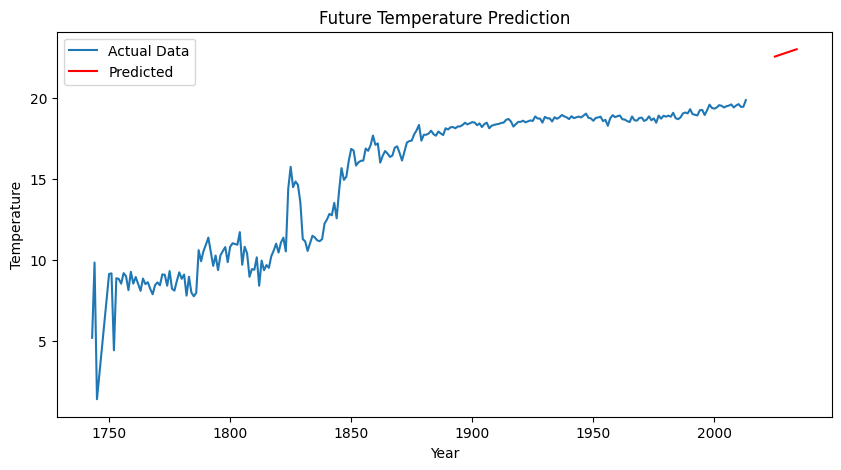

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original data
plt.plot(X, y, label='Actual Data')

# Future prediction
plt.plot(future_years, predictions, color='red', label='Predicted')

plt.legend()
plt.title("Future Temperature Prediction")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

In [32]:
import pandas as pd
import seaborn as sns

print("Environment Ready ✅")

Environment Ready ✅


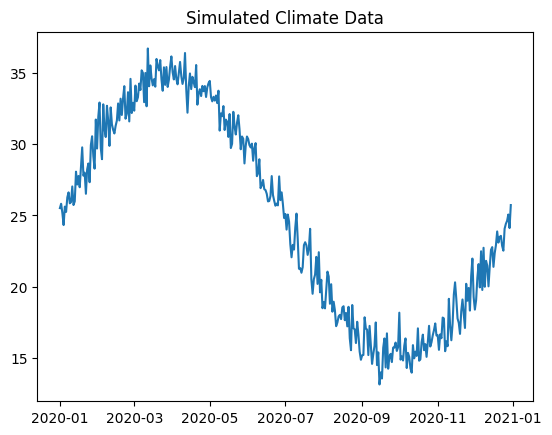

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
dates = pd.date_range(start='2020-01-01', periods=365)

temp = 25 + 10*np.sin(np.arange(365)/365*2*np.pi) + np.random.normal(0,1,365)

df_sim = pd.DataFrame({
    'date': dates,
    'temperature': temp
})

plt.plot(df_sim['date'], df_sim['temperature'])
plt.title("Simulated Climate Data")
plt.show()